# 05 · Exponential Smoothing

Chapter 04's two strongest baselines sit at opposite extremes. **Naive** puts all its weight on today. The **mean** spreads its weight equally over every day ever recorded. Exponential smoothing sits between them: a weighted average in which **recent observations count more and older ones fade away geometrically**. Add components for trend and seasonality and you get a family of models that has powered business and supply-chain forecasting since the 1950s, and still performs remarkably well in forecasting competitions.

This chapter builds the family up one component at a time, then puts it through the same honest backtest as the baselines. The results are instructive in both directions. On one of our series exponential smoothing is excellent. On the other it runs into a mismatch between its assumptions and the data, and understanding *why* is the real lesson.

**By the end of this chapter you will be able to**

- implement simple exponential smoothing from scratch and explain the smoothing parameter α
- explain how α is estimated, and why the **fitting objective** matters as much as the model
- extend the model with **trend** (Holt), **damped trend** and **seasonality** (Holt-Winters)
- use the **ETS** state-space framework for model selection by AIC and for prediction intervals
- judge when exponential smoothing's core assumption, *the level persists*, fits a series

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

import tsutils

tsutils.set_style()
pd.set_option("display.precision", 2)

daily = tsutils.load_daily_pm25()
y, actual = daily["pm25"], daily["actual"]
origins, H = tsutils.BACKTEST_ORIGINS, tsutils.HORIZON

---
## 1. Simple exponential smoothing (SES)

SES keeps a single number, the **level** $\ell_t$, and updates it each time a new observation arrives:

$$\ell_t = \alpha\, y_t + (1 - \alpha)\, \ell_{t-1}, \qquad 0 < \alpha \le 1.$$

The forecast for every future step is simply the latest level: $\hat y_{t+h} = \ell_t$.

Unrolling the recursion shows where the name comes from. The level is a weighted average of all past observations,

$$\ell_t = \alpha\, y_t + \alpha(1-\alpha)\, y_{t-1} + \alpha(1-\alpha)^2\, y_{t-2} + \dots$$

with weights that shrink **exponentially** with age. $\alpha$ sets how fast. With $\alpha = 1$, SES *is* the naive forecast. As $\alpha \to 0$ it approaches a long-run average.

The same update can be written in **error-correction** form, which is often more intuitive:

$$\ell_t = \ell_{t-1} + \alpha\,(y_t - \ell_{t-1}).$$

Each day we nudge the level towards the new observation by a fraction $\alpha$ of the surprise. $\alpha$ works like a learning rate.

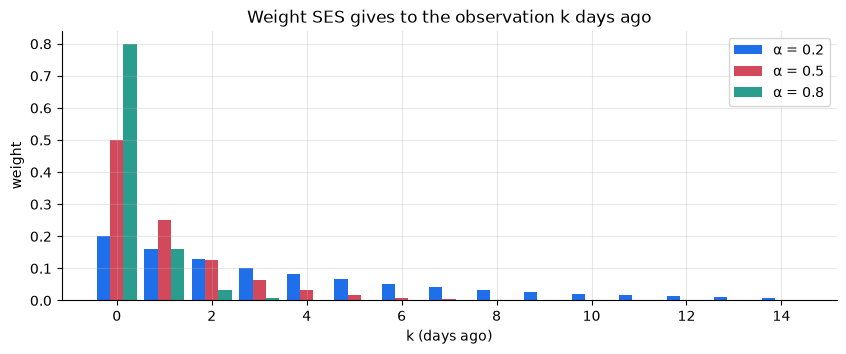

In [2]:
lags = np.arange(15)
fig, ax = plt.subplots(figsize=(10, 3.5))
for i, alpha in enumerate([0.2, 0.5, 0.8]):
    ax.bar(lags + (i - 1) * 0.28, alpha * (1 - alpha) ** lags, width=0.28, label=f"α = {alpha}")
ax.set(title="Weight SES gives to the observation k days ago", xlabel="k (days ago)", ylabel="weight")
ax.legend();

Let's implement it. SES needs a starting level $\ell_0$ before the first observation; the simplest choice is the first observation itself.

In [3]:
def ses_levels(values, alpha, initial_level):
    """Level after each observation: l_t = alpha * y_t + (1 - alpha) * l_{t-1}."""
    levels = np.empty(len(values))
    level = initial_level
    for t, value in enumerate(values):
        level = alpha * value + (1 - alpha) * level
        levels[t] = level
    return levels

train = y[:"2013-12-31"]
ours = ses_levels(train.to_numpy(), alpha=0.3, initial_level=train.iloc[0])

library = SimpleExpSmoothing(train.to_numpy(), initialization_method="known",
                             initial_level=train.iloc[0]).fit(smoothing_level=0.3, optimized=False)
print("levels match statsmodels:", np.allclose(ours, library.level))

levels match statsmodels: True


---
## 2. Estimating α

How much should yesterday count? statsmodels picks $\alpha$ (and the starting level) by minimising the **sum of squared one-step-ahead errors** over the training data: at each day, how far was yesterday's level from today's value? We can draw that objective ourselves.

We'll work on the **log** scale. Chapter 04 showed that MAE rewards forecasting the median, and exponentiating a forecast made on the log scale gives a median-type forecast, exactly what we want.

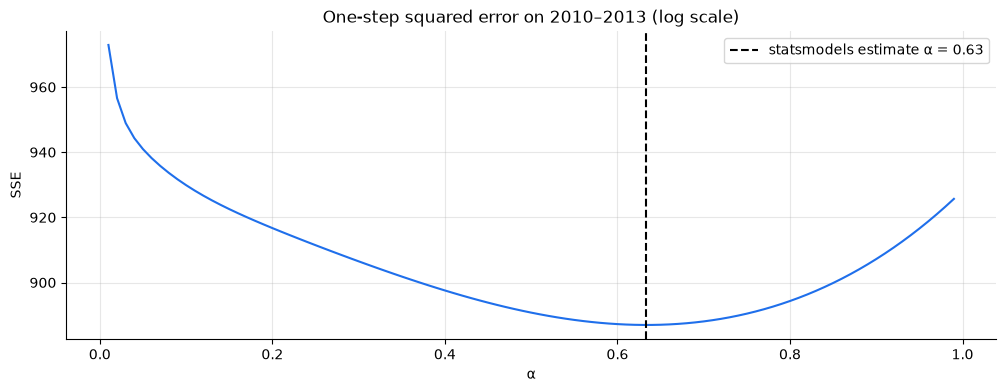

In [4]:
log_train = np.log(train.to_numpy())
alphas = np.round(np.arange(0.01, 1.0, 0.01), 2)

def one_step_sse(values, alpha):
    levels = ses_levels(values, alpha, initial_level=values[0])
    errors = values[1:] - levels[:-1]          # forecast for day t is the level after day t-1
    return np.sum(errors ** 2)

sse = pd.Series([one_step_sse(log_train, a) for a in alphas], index=alphas)
fitted = SimpleExpSmoothing(log_train, initialization_method="estimated").fit()

ax = sse.plot(title="One-step squared error on 2010–2013 (log scale)", xlabel="α", ylabel="SSE")
ax.axvline(fitted.params["smoothing_level"], color="k", ls="--",
           label=f"statsmodels estimate α = {fitted.params['smoothing_level']:.2f}")
ax.legend();

The curve has a clear minimum at a fairly **high** $\alpha$: SES wants to follow yesterday closely. That's consistent with chapter 04, where naive was the best one-day-ahead baseline. statsmodels lands in the same place (small differences come from also estimating the starting level).

---
## 3. SES on the PM2.5 task

Now the honest test: the chapter 04 backtest, refitting $\alpha$ at every origin so each forecast only uses data up to that day.

In [5]:
def ses_log_forecast(history, horizon):
    model = SimpleExpSmoothing(np.log(history.to_numpy()), initialization_method="estimated").fit()
    return np.exp(model.forecast(horizon))

ses_scores = tsutils.evaluate(tsutils.backtest(y, ses_log_forecast, origins, H, actuals=actual))
tsutils.save_scores("SES (log)", ses_scores)

board = tsutils.load_scores().pivot(index="h", columns="model", values="MAE")
comparison = board[["naive", "climatology (median)"]].assign(**{"SES (log)": ses_scores["MAE"]})
comparison

model,naive,climatology (median),SES (log)
h,,,
1,51.10,56.08,52.06
2,72.24,56.56,69.29
3,81.27,56.77,74.87
4,81.56,57.13,73.41
5,76.29,57.10,68.14
6,75.10,57.13,68.64
7,76.94,57.07,69.07


**SES loses.** It roughly ties naive for tomorrow, and from day 2 it's well behind climatology, the simple seasonal baseline.

The reason goes to the heart of the method. **SES assumes the level persists**: whatever level it has estimated today is its forecast for next week too. That's the right assumption for a series whose changes are permanent, like a random walk observed with noise (Exercise 3). But chapter 03 showed PM2.5 **mean-reverts** with a half-life of about a day. A smog peak today is gone by the weekend. SES, fitted to follow yesterday closely, confidently carries today's peak forward for a week.

There's a second, subtler problem: **the fitting objective doesn't match the use.** $\alpha$ was chosen to minimise *one-step* errors, but we judge the model on steps 1 through 7. What would $\alpha$ look like if we chose it separately for each horizon?

---
## 4. Matching the objective to the task

A useful property of SES with a fixed $\alpha$ is that it's a **causal filter**: the level on day $t$ uses only data up to day $t$. So we can run it once over the whole series and read off the forecast at each origin without leaking anything. That makes it cheap to try many values of $\alpha$.

We choose $\alpha$ for each horizon on the **2013** backtest, then report on **2014**, following the discipline from chapter 04.

h,1,2,3,4,5,6,7
best α on 2013,0.61,0.03,0.01,0.01,0.01,0.01,0.01


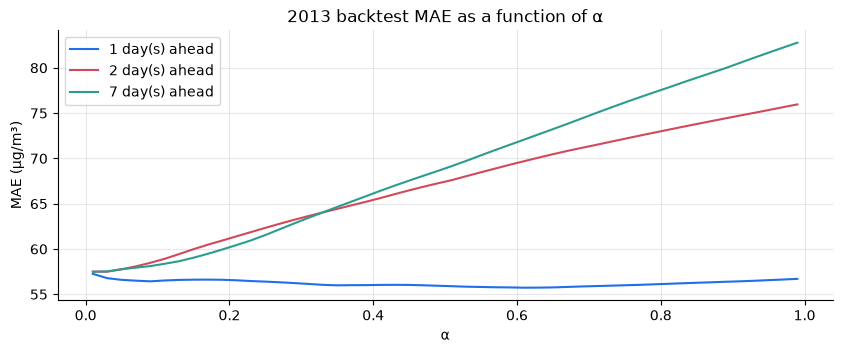

In [6]:
log_y = np.log(y.to_numpy())
tuning_origins = pd.date_range("2012-12-31", "2013-12-24", freq="D")

def fixed_alpha_scores(alpha, origins_):
    level = pd.Series(np.exp(ses_levels(log_y, alpha, log_y[0])), index=y.index)
    forecaster = lambda history, horizon: np.full(horizon, level[history.index[-1]])
    return tsutils.evaluate(tsutils.backtest(y, forecaster, origins_, H, actuals=actual))

tuning = pd.DataFrame({a: fixed_alpha_scores(a, tuning_origins)["MAE"] for a in alphas[::2]}).T
best_alpha = tuning.idxmin()

fig, ax = plt.subplots(figsize=(10, 3.5))
for h in [1, 2, 7]:
    tuning[h].plot(ax=ax, label=f"{h} day(s) ahead")
ax.set(title="2013 backtest MAE as a function of α", xlabel="α", ylabel="MAE (µg/m³)")
ax.legend()
best_alpha.rename("best α on 2013").to_frame().T

Two completely different answers:

- **For tomorrow**, the best $\alpha$ is high, close to what the one-step fit found: follow yesterday. The curve is remarkably flat, though, so for one day ahead almost any $\alpha$ does about as well.
- **For two days and beyond**, the best $\alpha$ is tiny, 0.01–0.03, at the bottom of the range we tried. Ignore the last few days almost entirely and use a long average. With weights fading as $(1-\alpha)^k$, that average effectively spans the past one to three months.

In other words, the data are telling us that *recent information is valuable for one day and then worthless*, the same one-day half-life we keep meeting. A single $\alpha$ can't represent that, but a separate $\alpha$ per horizon can. Let's score that on 2014:

In [7]:
per_horizon = pd.concat(
    [fixed_alpha_scores(best_alpha[h], origins).loc[[h]] for h in range(1, H + 1)])
tsutils.save_scores("SES (log), α per horizon", per_horizon)

comparison["SES (log), α per horizon"] = per_horizon["MAE"]
comparison

model,naive,climatology (median),SES (log),"SES (log), α per horizon"
h,,,,
1,51.10,56.08,52.06,52.13
2,72.24,56.56,69.29,56.28
3,81.27,56.77,74.87,56.08
4,81.56,57.13,73.41,56.35
5,76.29,57.10,68.14,56.31
6,75.10,57.13,68.64,56.32
7,76.94,57.07,69.07,56.26


Choosing $\alpha$ for the job transforms SES. It stays within about 1 µg/m³ of naive at one day, and it now **edges out climatology from day 2 onwards**. The long average tracks the slowly drifting level (chapter 03's 2015-style shifts) a little better than a fixed seasonal profile does.

This is known as a **direct** forecasting strategy: a separately tuned forecaster for each horizon. We'll meet it again in the machine-learning chapter. The broader lesson reaches well beyond SES:

> **A model is only as good as the objective it was fitted to.** Fitting for one-step accuracy and then forecasting a week ahead is a mismatch many real systems quietly suffer from.

Still, even the tuned version only *switches* between "yesterday" and "long average". It can't express the **gradual** fade from one to the other that mean reversion implies. Chapter 04's damped-persistence exercise did that by hand, and chapter 06's AR models will do it properly.

---
## 5. Adding a trend: Holt's method

Where exponential smoothing really comes into its own is on series with **persistent** structure. Our showcase is the Mauna Loa CO₂ record: a trend that persists for decades and a seasonal cycle that repeats every year.

**Holt's linear method** adds a second smoothed quantity, the **trend** (slope) $b_t$:

$$\begin{aligned}
\ell_t &= \alpha\, y_t + (1-\alpha)(\ell_{t-1} + b_{t-1}) \\
b_t &= \beta\,(\ell_t - \ell_{t-1}) + (1-\beta)\, b_{t-1} \\
\hat y_{t+h} &= \ell_t + h\, b_t
\end{aligned}$$

The level is updated towards the new observation, starting from where last period's level *plus* slope predicted we'd be. The slope is then updated towards the latest change in level.

Holt's forecasts are straight lines that continue forever, which is often too confident. The **damped trend** (Gardner & McKenzie, 1985) adds a parameter $0 < \phi < 1$ that makes the slope fade out:

$$\hat y_{t+h} = \ell_t + (\phi + \phi^2 + \dots + \phi^h)\, b_t.$$

Forecasts then level off rather than climbing forever. Damped trend is one of the most dependable methods in forecasting competitions.

## 6. Adding seasonality: Holt-Winters

**Holt-Winters** adds a seasonal component $s_t$ with period $m$. In the **additive** version:

$$\begin{aligned}
\ell_t &= \alpha\,(y_t - s_{t-m}) + (1-\alpha)(\ell_{t-1} + b_{t-1}) \\
b_t &= \beta\,(\ell_t - \ell_{t-1}) + (1-\beta)\, b_{t-1} \\
s_t &= \gamma\,(y_t - \ell_{t-1} - b_{t-1}) + (1-\gamma)\, s_{t-m} \\
\hat y_{t+h} &= \ell_t + h\, b_t + s_{t+h-m}
\end{aligned}$$

(For $h > m$, reuse the most recent estimate of the matching season.) The **multiplicative** version divides by the seasonal factor instead of subtracting it, which suits series whose seasonal swings grow with the level (chapter 02).

Each smoothing parameter ($\alpha$, $\beta$, $\gamma$) controls how quickly its component adapts, and all are estimated from the data.

In [8]:
co2 = sm.datasets.co2.load_pandas().data["co2"].resample("MS").mean().interpolate()

def es_forecaster(**settings):
    """Build a forecaster that refits statsmodels' ExponentialSmoothing at each origin."""
    def forecast(history, horizon):
        model = ExponentialSmoothing(history.to_numpy(), initialization_method="estimated", **settings)
        return model.fit().forecast(horizon)
    return forecast

def seasonal_naive_drift(history, horizon, period=12):
    """Chapter 04's best CO₂ baseline: last year's values plus one year's growth per year ahead."""
    growth = history.iloc[-period:].mean() - history.iloc[-2 * period:-period].mean()
    last_year = np.tile(history.iloc[-period:].to_numpy(), int(np.ceil(horizon / period)))[:horizon]
    return last_year + growth * np.ceil(np.arange(1, horizon + 1) / period)

co2_models = {
    "baseline: seasonal naive + drift": seasonal_naive_drift,
    "SES": es_forecaster(),
    "Holt": es_forecaster(trend="add"),
    "Holt, damped": es_forecaster(trend="add", damped_trend=True),
    "Holt-Winters (additive)": es_forecaster(trend="add", seasonal="add", seasonal_periods=12),
    "Holt-Winters (multiplicative)": es_forecaster(trend="add", seasonal="mul", seasonal_periods=12),
}

First a picture: all models forecasting 12 months ahead from a single origin, January 1995.

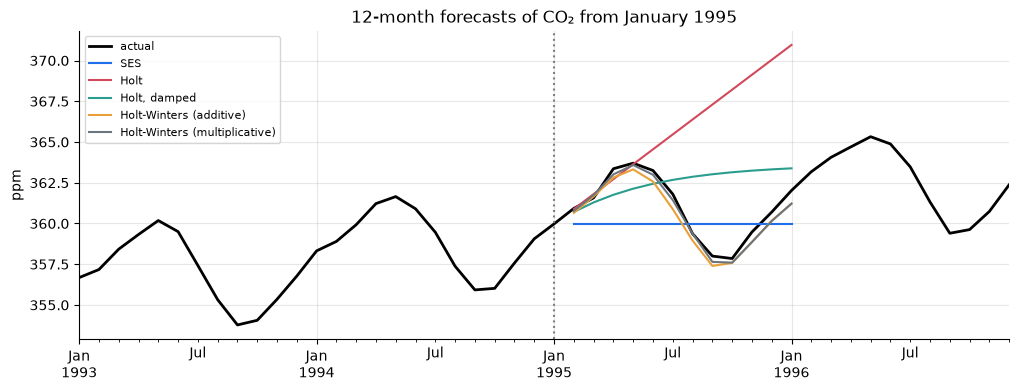

In [9]:
co2_origin = pd.Timestamp("1995-01-01")
history = co2[:co2_origin]
future_index = pd.date_range(co2_origin + pd.offsets.MonthBegin(1), periods=12, freq="MS")

ax = co2["1993":"1996"].plot(color="k", lw=2, label="actual")
for name, forecaster in list(co2_models.items())[1:]:
    pd.Series(forecaster(history, 12), index=future_index).plot(ax=ax, label=name)
ax.axvline(co2_origin, color="0.5", ls=":")
ax.set(title="12-month forecasts of CO₂ from January 1995", ylabel="ppm")
ax.legend(fontsize=8);

SES draws a flat line and Holt extrapolates whatever slope the seasonal wiggle happens to have at the origin. Only Holt-Winters understands that the wiggle *repeats*. Now the full backtest: a forecast from every month from 1990 to 2000, 12 months ahead.

In [10]:
co2_origins = pd.date_range("1990-01-01", "2000-12-01", freq="MS")
co2_scores = {name: tsutils.evaluate(tsutils.backtest(co2, f, co2_origins, 12))
              for name, f in co2_models.items()}

pd.DataFrame({name: s["MAE"] for name, s in co2_scores.items()}).loc[[1, 3, 6, 12]].T

h,1,3,6,12
baseline: seasonal naive + drift,0.52,0.61,0.72,0.85
SES,1.14,2.91,3.78,1.52
Holt,0.73,3.28,8.15,13.25
"Holt, damped",0.70,2.68,5.22,3.94
Holt-Winters (additive),0.25,0.37,0.52,0.66
Holt-Winters (multiplicative),0.25,0.37,0.50,0.64


On CO₂ the picture reverses completely:

- **Holt-Winters beats the best baseline at every horizon**, cutting its error roughly in half at short horizons. This is exponential smoothing in its element: a series whose level, slope and seasonal shape all *persist*, so projecting them forward is exactly right.
- **Holt without seasonality is disastrous** at long horizons. It mistakes the seasonal upswing for a trend and extrapolates it. A misspecified trend is worse than none, which is why **SES**, flat but harmless, beats it.
- **Damping** rescues Holt partially, by limiting how far a bad slope is extrapolated.
- The additive and multiplicative seasonal versions are nearly tied. Over this range CO₂'s seasonal swing grows only slightly (chapter 02), so either form works.

Put the two series side by side and the rule is clear: **exponential smoothing projects the current state forward.** It excels when the state persists (CO₂) and struggles when the series keeps snapping back (PM2.5).

---
## 7. The ETS framework: a statistical model underneath

The methods above were invented as sensible recipes. In the 2000s, Hyndman and colleagues showed that each one corresponds to a **state-space model** with an explicit error term. That gives three things the recipes lack:

1. a **likelihood**, so models can be compared with information criteria such as **AIC**
2. **prediction intervals** derived from the model
3. a clean **taxonomy**: each model is labelled **E**rror, **T**rend, **S**easonal

| Component | Options |
|---|---|
| Error | **A**dditive, **M**ultiplicative |
| Trend | **N**one, **A**dditive, **A**d (additive damped) |
| Seasonal | **N**one, **A**dditive, **M**ultiplicative |

So SES is ETS(A,N,N), Holt is ETS(A,A,N), and additive Holt-Winters is ETS(A,A,A). The error type doesn't change the point forecasts, but it does change the likelihood and the intervals.

Let's fit several ETS models to CO₂ up to the end of 1989 and compare their AIC. Lower is better: AIC rewards fit and penalises extra parameters.

In [11]:
co2_train = co2[:"1989-12"]
ets_candidates = {
    "A,N,N": dict(error="add"),
    "A,A,N": dict(error="add", trend="add"),
    "A,Ad,N": dict(error="add", trend="add", damped_trend=True),
    "A,A,A": dict(error="add", trend="add", seasonal="add"),
    "A,Ad,A": dict(error="add", trend="add", damped_trend=True, seasonal="add"),
    "A,A,M": dict(error="add", trend="add", seasonal="mul"),
    "M,A,M": dict(error="mul", trend="add", seasonal="mul"),
}

def fit_ets(series, settings):
    periods = 12 if settings.get("seasonal") else None
    return ETSModel(series, seasonal_periods=periods, **settings).fit(disp=False)

pd.Series({label: fit_ets(co2_train, s).aic for label, s in ets_candidates.items()},
          name="AIC").sort_values().to_frame()

,AIC
"A,A,M",174.18
"M,A,M",178.78
"A,A,A",202.87
"A,Ad,A",221.30
"A,Ad,N",954.93
"A,N,N",1199.87
"A,A,N",1201.29


The seasonal models win by a huge margin. Among them the multiplicative-seasonal ones come out slightly ahead, and damping doesn't help, because CO₂'s trend doesn't fade. (Exercise 4 checks whether AIC's ranking agrees with an out-of-sample backtest.)

AIC comparisons are only valid between models fitted to **the same data on the same scale**. Never compare the AIC of a model on $y$ with one on $\log y$.

### Prediction intervals, and whether to trust them

ETS gives intervals directly. Let's draw an 80% interval, then check its coverage across the whole 1990–2000 backtest, as we did with the empirical intervals in chapter 04.

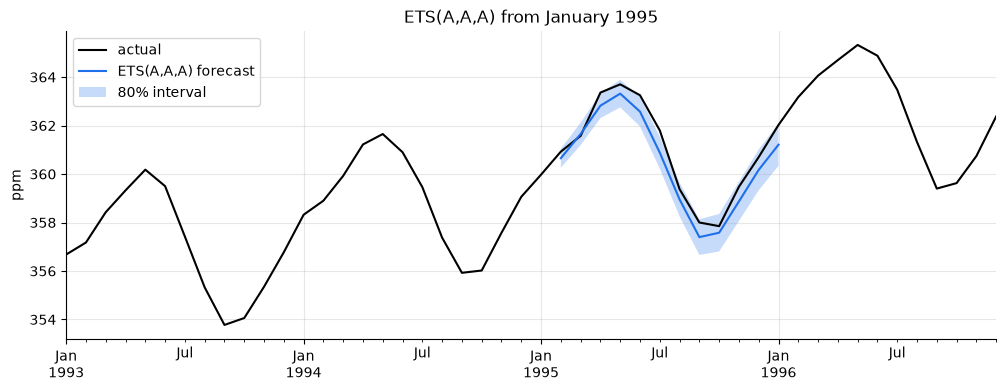

In [12]:
ets_model = fit_ets(co2[:co2_origin], ets_candidates["A,A,A"])
frame = ets_model.get_prediction(start=len(co2[:co2_origin]), end=len(co2[:co2_origin]) + 11).summary_frame(alpha=0.2)
frame.index = future_index

ax = co2["1993":"1996"].plot(color="k", label="actual")
frame["mean"].plot(ax=ax, label="ETS(A,A,A) forecast")
ax.fill_between(frame.index, frame["pi_lower"], frame["pi_upper"], alpha=0.25, label="80% interval")
ax.set(title="ETS(A,A,A) from January 1995", ylabel="ppm")
ax.legend(loc="upper left");

In [13]:
inside = []
for origin_ in co2_origins:
    history_ = co2[:origin_]
    fit = fit_ets(history_, ets_candidates["A,A,A"])
    pi = fit.get_prediction(start=len(history_), end=len(history_) + 11).summary_frame(alpha=0.2)
    target = co2.reindex(pd.date_range(origin_ + pd.offsets.MonthBegin(1), periods=12, freq="MS")).to_numpy()
    hit = (target >= pi["pi_lower"].to_numpy()) & (target <= pi["pi_upper"].to_numpy())
    inside.append(np.where(np.isnan(target), np.nan, hit))

coverage = pd.Series(np.nanmean(inside, axis=0), index=pd.RangeIndex(1, 13, name="months ahead"), name="coverage")
coverage.to_frame().T.style.format("{:.0%}")

months ahead,1,2,3,4,5,6,7,8,9,10,11,12
coverage,81%,76%,77%,70%,71%,73%,73%,74%,76%,77%,80%,80%


The target is 80%, but actual coverage falls to the low 70s at medium horizons: the model's intervals are **somewhat too narrow**. Model-based intervals assume the model is exactly right, with errors that are independent and identically distributed. Real series violate that. Here, bursts of faster CO₂ growth in strong El Niño years (chapter 03) are larger than anything the model's error term expects.

Treat model-based intervals as a starting point and **verify coverage out of sample** before relying on them. Chapter 04's empirical intervals are a robust alternative.

---
## Exercises

### Exercise 1: Holt from scratch
Implement Holt's linear method (section 5) as `holt_forecast(values, alpha, beta, initial_level, initial_trend, horizon)`. Check it against statsmodels on `co2_train`, with `alpha=0.5`, `beta=0.1`, a starting level equal to the first observation and a starting trend of 0.1. In statsmodels, use `initialization_method="known"`, and `optimized=False` in `fit`.

<details><summary>Solution</summary>

```python
def holt_forecast(values, alpha, beta, initial_level, initial_trend, horizon):
    level, trend = initial_level, initial_trend
    for value in values:
        previous_level = level
        level = alpha * value + (1 - alpha) * (level + trend)
        trend = beta * (level - previous_level) + (1 - beta) * trend
    return level + trend * np.arange(1, horizon + 1)

values = co2_train.to_numpy()
lib = ExponentialSmoothing(values, trend="add", initialization_method="known",
                           initial_level=values[0], initial_trend=0.1).fit(
    smoothing_level=0.5, smoothing_trend=0.1, optimized=False)
print(np.allclose(lib.forecast(12), holt_forecast(values, 0.5, 0.1, values[0], 0.1, 12)))
```
</details>

### Exercise 2: To damp or not to damp, a decade ahead
Fit additive Holt-Winters to CO₂ up to the end of 1989, once with and once without a damped trend. Forecast all the way to December 2001, 144 months. Compare each forecast's MAE in the first year and in the last three years. What's the estimated damping parameter φ, and why does damping hurt here?

<details><summary>Solution</summary>

```python
future = co2["1990":]
for damped in [False, True]:
    fit = ExponentialSmoothing(co2_train, trend="add", damped_trend=damped, seasonal="add",
                               seasonal_periods=12, initialization_method="estimated").fit()
    fc = fit.forecast(len(future)).to_numpy()
    err = np.abs(fc - future.to_numpy())
    phi = fit.params["damping_trend"] if damped else 1.0
    print(f"damped={damped}: φ={phi:.3f}  first-year MAE {err[:12].mean():.2f}  "
          f"last-3-years MAE {err[-36:].mean():.2f}  Dec 2001 forecast {fc[-1]:.1f} vs actual {future.iloc[-1]:.1f}")
```
In the first year the two are indistinguishable. A decade out, the damped version is clearly worse. With φ just below 1, the slope fades slowly but steadily, and after 12 years it has flattened noticeably, while real CO₂ growth didn't slow; it accelerated. Both forecasts end up too low, and the undamped one less so. Damping is a good default when trends are uncertain. It's the wrong choice when there's strong physical reason to expect the trend to continue.
</details>

### Exercise 3: When is "the level persists" the right assumption?
Simulate two series of 1,500 daily values:
- a **local level** series, a random walk observed with noise: `np.cumsum(rng.normal(0, 0.5, n)) + rng.normal(0, 1, n)`
- a **mean-reverting** AR(1) with φ = 0.5, as in chapter 03

Backtest SES (with α estimated), naive and the historical mean on each, with origins from day 1,000 to 1,490 and a 5-step horizon. Which wins on each series?

<details><summary>Solution</summary>

```python
rng = np.random.default_rng(1)
n = 1500
index = pd.date_range("2000-01-01", periods=n, freq="D")
local_level = np.cumsum(rng.normal(0, 0.5, n)) + rng.normal(0, 1, n)
shocks = rng.normal(size=n)
ar = np.zeros(n)
for t in range(1, n):
    ar[t] = 0.5 * ar[t - 1] + shocks[t]

ses = lambda h, H: SimpleExpSmoothing(h.to_numpy(), initialization_method="estimated").fit().forecast(H)
mean = lambda h, H: np.full(H, h.mean())
sim_origins = index[1000:1490]

pd.DataFrame({
    (series_name, model_name): tsutils.evaluate(
        tsutils.backtest(pd.Series(values, index=index), f, sim_origins, 5))["MAE"].loc[[1, 5]]
    for series_name, values in [("local level", local_level), ("AR(1), φ=0.5", ar)]
    for model_name, f in [("SES", ses), ("naive", tsutils.naive_forecast), ("mean", mean)]
}).T
```
On the **local level** series SES wins at both horizons: it averages away the observation noise better than naive, and the mean is hopeless because the level really does wander. On the **AR(1)**, SES still beats naive, but at 5 steps ahead the plain **mean** beats SES, because the series has returned to its mean and SES is still carrying old information forward. SES is, in fact, the optimal forecast for the local-level model. Match the model's assumptions to the data's behaviour.
</details>

### Exercise 4: Does AIC pick the model that forecasts best?
For the ETS configurations `A,A,A`, `A,A,M`, `M,A,M` and `A,Ad,A`, record the AIC when fitted to `co2_train`. Then run a backtest with **yearly** origins (December 1989, 1990, …, 1999) and a 12-month horizon, refitting ETS at each origin, and compute the average MAE. Do the two rankings agree?

<details><summary>Solution</summary>

```python
yearly_origins = pd.date_range("1989-12-01", "1999-12-01", freq="12MS")
rows = {}
for label in ["A,A,A", "A,A,M", "M,A,M", "A,Ad,A"]:
    settings = ets_candidates[label]
    forecaster = lambda h, H, s=settings: fit_ets(h, s).forecast(H).to_numpy()
    rows[label] = {
        "AIC (fit to 1958–1989)": fit_ets(co2_train, settings).aic,
        "backtest MAE (1990–2000)": tsutils.evaluate(tsutils.backtest(co2, forecaster, yearly_origins, 12))["MAE"].mean(),
    }
pd.DataFrame(rows).T.sort_values("AIC (fit to 1958–1989)")
```
Here the rankings agree: the two multiplicative-seasonal models have the lowest AIC and the lowest backtest error, followed by A,A,A and then the damped model. That's reassuring, but not guaranteed in general. AIC measures in-sample fit, penalised for complexity, under the model's own assumptions. The backtest measures what you actually care about. When they disagree, trust the backtest, and when the backtest is too expensive to run, AIC is a reasonable proxy.
</details>

---
## Key takeaways

- Exponential smoothing is a weighted average with **geometrically decaying weights**. α sets the memory: α = 1 is naive, small α is a long average.
- Holt adds a **trend**, damping stops the trend from **extrapolating forever**, and Holt-Winters adds **seasonality**. ETS puts them all in one statistical framework with **AIC** and **prediction intervals**.
- The core assumption is that **the current state persists**. On CO₂, which persists, Holt-Winters halves the best baseline's error. On PM2.5, which mean-reverts within a day, SES can't beat the simple baselines.
- **Fit to the objective you'll be judged on.** Choosing α per horizon turned SES from a loser into a narrow winner on PM2.5, a direct forecasting strategy.
- Model-based intervals assume the model is right. **Check their coverage** out of sample: ETS ran a little narrow on CO₂.
- New scoreboard entries: `SES (log)` and `SES (log), α per horizon`.

**Next:** *06 · Autocorrelation and ARMA*. We'll look at models built precisely for series that remember the past *and* revert to a mean: the gradual fade that exponential smoothing can't express.